
EDA: Viral Posts by Platform (VK vs TG)
Explore drivers of `is_viral` by platform on social_wide_final.csv.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import re
import requests
from bs4 import BeautifulSoup
import seaborn as sns
import emoji
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
sns.set(style='whitegrid')

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
%matplotlib inline

In [ ]:
DATA_DIR = Path("../data/processed")
FINAL_CSV = DATA_DIR / "social_wide_final.csv"
SAVE_DIR = Path("eda_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
read_kwargs = dict(
    low_memory=False,
    dtype={
        "is_ad": "string",
        "image_url": "string",
        "tg_is_forwarded": "string",
        "tg_fwd_src_name": "string",
    },
)


In [8]:
df = pd.read_csv(FINAL_CSV, **read_kwargs)
# print(f"Loaded: {df}  rows={len(df):,}, cols={df.shape[1]}")
df.head(3)

,platform,source_name,source_link,followers,post_id,published_at,text,text_len,has_photo,has_video,has_link,has_poll,is_ad,link,vk_group_id,vk_from_id,image_url,likes,comments,reposts,likes_2025-06-07,reposts_2025-06-07,comments_2025-06-07,tg_channel_id,tg_channel_username,tg_is_forwarded,tg_fwd_src_id,tg_fwd_src_name,tg_fwd_src_msg_id,likes_2025-08-15,comments_2025-08-15,reposts_2025-08-15,collected_at_2025-08-15,original_collected_at_2025-08-15,original_comments_2025-08-15,original_likes_2025-08-15,original_reposts_2025-08-15,er_2025-06-07,er_2025-08-15,engagement_rate,er_final,emojis,num_emojis,num_hashtags,num_mentions,is_ad_by_text,clean_text,lemma_text,is_ad_final,published_at_dt,hour_posted,dow_posted,is_weekend,likes_pf,comments_pf,reposts_pf,engagement_change,len_text,emojis_per_100_chars,hashtags_per_100_chars,mentions_per_100_chars,log_followers,has_fwd_src,has_fwd_msg_id,is_viral
0,vk,Рифмы и Панчи,https://vk.com/club28905875,5500636,35113066,1748947178,☄ ИИ НАПИШЕТ ДИПЛОМ ЗА ВАС! Собрали большую шп...,182,True,False,False,False,False,https://vk.com/club28905875,28905875.0,-28905875.0,https://sun9-15.userapi.com/s/v1/ig2/9Mogdi0ir...,300.0,1.0,613.0,474.0,880.0,1.0,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000160,NaN,0.000111,0.000160,☄ 👇,2,0,0,False,ии напишет диплом за вас! собрали большую шпор...,ия написать диплом вас! собрать больший шпор т...,0,2025-06-03 10:39:38,10.0,1.0,0,0.000055,1.817972e-07,0.000111,0.000049,182,1.098901,0.0,0.0,15.520374,0,0,0
1,vk,Рифмы и Панчи,https://vk.com/club28905875,5500636,35116660,1748947178,В ROSTIC`S ЗАВЕЗЛИ ТАЙСКОЕ МЕНЮ — летние новин...,423,True,False,False,False,False,https://vk.com/club28905875,28905875.0,-28905875.0,https://sun9-45.userapi.com/s/v1/if2/VAggYdyZT...,36.0,4.0,169.0,350.0,1490.0,17.0,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000271,NaN,0.000031,0.000271,😮 🤨 ➖,3,0,0,False,в завезли тайское меню летние новинки уже можн...,завезти тайский меню летний новинка попробоват...,0,2025-06-03 10:39:38,10.0,1.0,0,0.000007,7.271886e-07,0.000031,0.000240,423,0.709220,0.0,0.0,15.520374,0,0,0
2,vk,Рифмы и Панчи,https://vk.com/club28905875,5500636,35116548,1748947178,Рабочий день обязаны сократить до 4-х часов пр...,604,True,False,False,False,False,https://vk.com/club28905875,28905875.0,-28905875.0,https://sun9-68.userapi.com/s/v1/if2/aPsqeBaiD...,147.0,11.0,250.0,627.0,1139.0,28.0,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000207,NaN,0.000045,0.000207,👨‍💻 🥵 ➖,3,0,0,False,рабочий день обязаны сократить до 4-х часов пр...,рабочий день обязать сократить 4-й час жара вы...,0,2025-06-03 10:39:38,10.0,1.0,0,0.000027,1.999769e-06,0.000045,0.000162,604,0.496689,0.0,0.0,15.520374,0,0,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18525 entries, 0 to 18524
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype                        
---  ------                            --------------  -----                        
 0   platform                          18525 non-null  string                       
 1   source_name                       18525 non-null  string                       
 2   source_link                       18525 non-null  string                       
 3   followers                         18525 non-null  int64                        
 4   post_id                           18525 non-null  int64                        
 5   published_at                      18525 non-null  object                       
 6   text                              18525 non-null  string                       
 7   text_len                          18525 non-null  int64                        
 8   has_photo                         18

In [ ]:
# convert data types

str_cols = [
    "platform", "source_name", "source_link", "text", "link", "image_url",
    "tg_channel_username", "tg_fwd_src_name", "emojis", "clean_text", "lemma_text"
]
for c in str_cols:
    if c in df.columns:
        df[c] = df[c].astype("string")

# булевы из 0/1/True/False
bool_like = ["has_photo","has_video","has_link","has_poll","is_ad_by_text"]
for c in bool_like:
    if c in df.columns:
        df[c] = df[c].astype(bool)


In [14]:

df['platform'].value_counts()
print("VK posts:", (df['platform'].str.lower() == 'vk').sum())
print("TG posts:", (df['platform'].str.lower() == 'tg').sum())


VK posts: 11823
TG posts: 6702


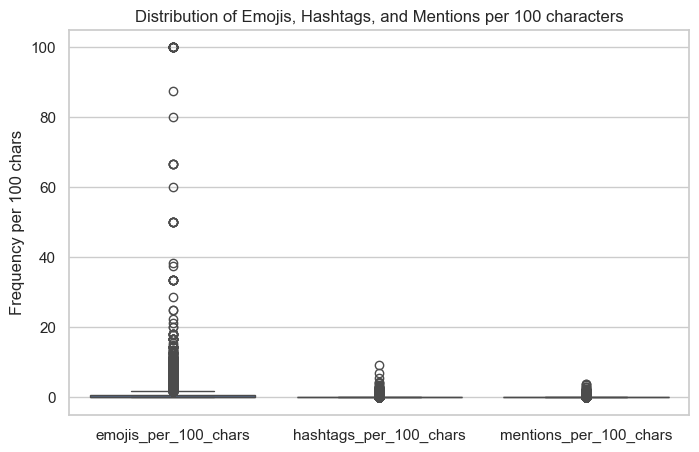

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['emojis_per_100_chars', 'hashtags_per_100_chars', 'mentions_per_100_chars']])
plt.title("Distribution of Emojis, Hashtags, and Mentions per 100 characters")
plt.ylabel("Frequency per 100 chars")
plt.show()


In [ ]:

df['platform'].value_counts()
print("VK posts:", (df['platform'].str.lower() == 'vk').sum())
print("TG posts:", (df['platform'].str.lower() == 'tg').sum())


VK posts: 11823
TG posts: 6702


In [ ]:
# Sentiment distribution

plt.figure(figsize=(7,5))
sns.countplot(x='sentiment_label', hue='is_viral', data=df)
plt.title('Sentiment Distribution in Viral and Non-Viral Posts')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.legend(title='Virality', labels=['Non-Viral', 'Viral'])
plt.show()

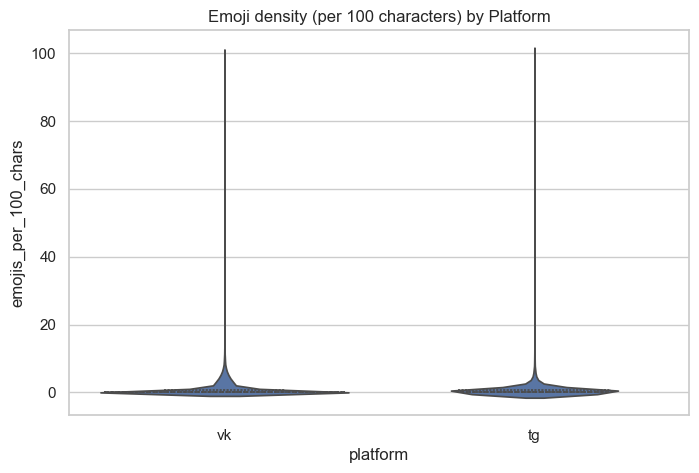

In [17]:

plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='platform', y='emojis_per_100_chars', inner='quartile')
plt.title("Emoji density (per 100 characters) by Platform")
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_2324\3737372425.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=fp)
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
C:\Users\MSI\AppData\Local\Temp\ipykernel_2324\3737372425.py:30: UserWarning: Glyph 129401 (\N{FACE HOLDING BACK TEARS}) missing from font(s) Segoe UI Emoji.
  plt.tight_layout(); plt.show()
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not fou

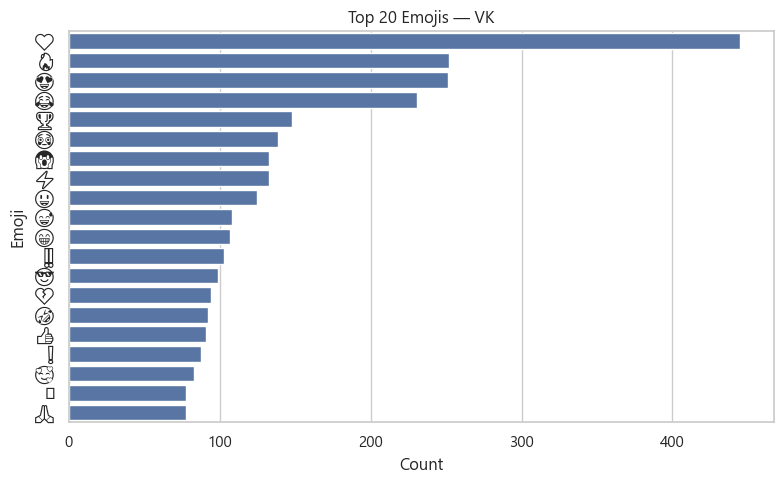

C:\Users\MSI\AppData\Local\Temp\ipykernel_2324\3737372425.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=fp)
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Color Emoji' not found.
findfont: Font family 'Noto Col

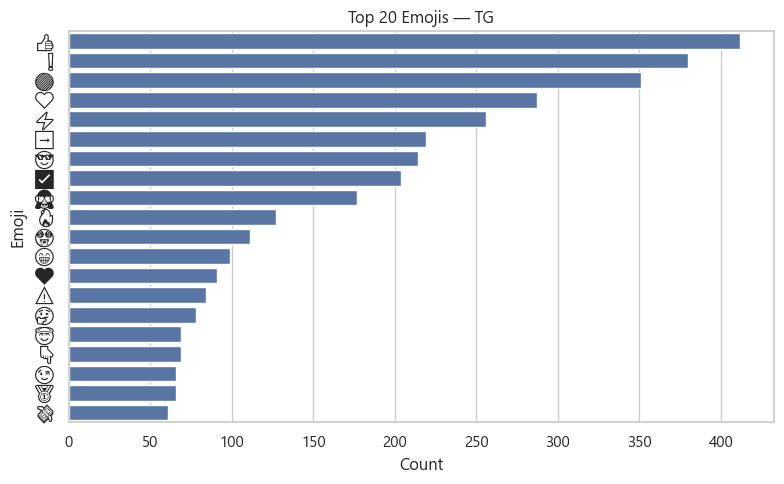

In [21]:
from collections import Counter
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['font.family'] = ['Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

def plot_top_emojis(data, platform, topn=15):
    # фильтруем по платформе
    subset = data[data['platform'].str.lower() == platform.lower()].copy()
    # собираем все эмодзи
    all_emojis = " ".join(subset['emojis'].dropna().astype(str)).replace('\ufe0f','').split()
    counts = Counter([e for e in all_emojis if e.strip()])
    if not counts:
        print(f"Нет эмодзи для {platform}")
        return
    labels, values = zip(*counts.most_common(topn))
    
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x=list(values), y=list(labels), orient='h')
    ax.set_title(f"Top {topn} Emojis — {platform.upper()}")
    ax.set_xlabel("Count"); ax.set_ylabel("Emoji")
    
    # явно задаём шрифт для отображения эмодзи
    from matplotlib.font_manager import FontProperties
    fp = FontProperties(family='Segoe UI Emoji', size=12)
    ax.set_yticklabels(labels, fontproperties=fp)
    
    plt.tight_layout(); plt.show()

# строим графики для VK и TG
plot_top_emojis(df, "vk", topn=20)
plot_top_emojis(df, "tg", topn=20)



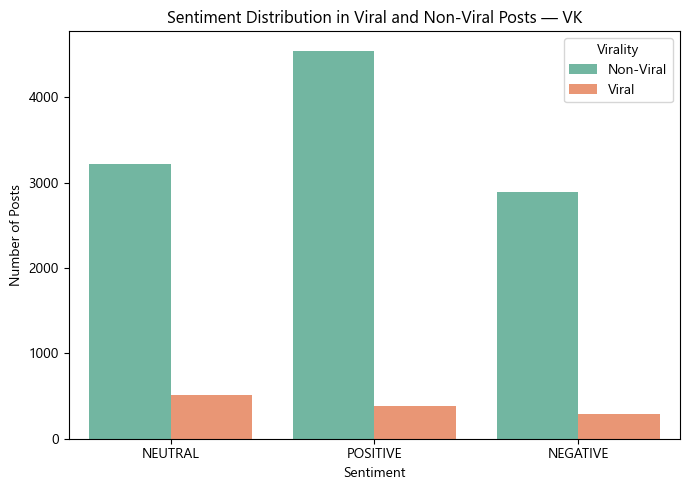

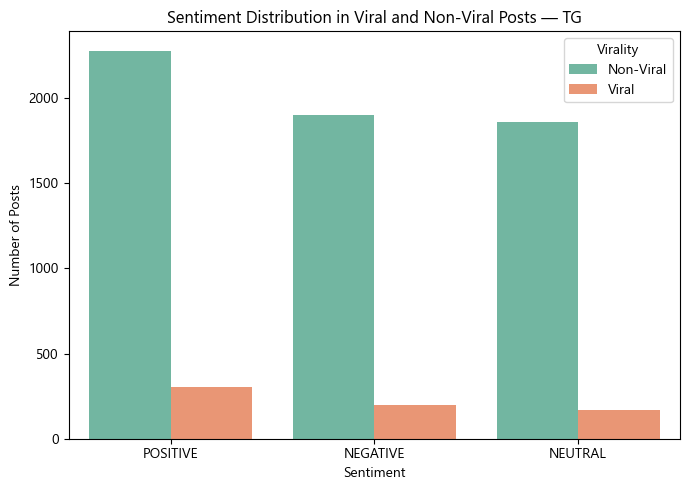

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Только те шрифты, которые точно есть в Windows
mpl.rcParams['font.family'] = ['Segoe UI Emoji', 'Segoe UI Symbol', 'Arial', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

def plot_sentiment_distribution(data, platform):
    subset = data[data['platform'].str.lower() == platform.lower()].copy()
    if subset.empty:
        print(f"No data for {platform}")
        return
    
    plt.figure(figsize=(7,5))
    sns.countplot(
        x='sentiment_label_hf', hue='is_viral', 
        data=subset, palette="Set2"
    )
    plt.title(f'Sentiment Distribution in Viral and Non-Viral Posts — {platform.upper()}')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Posts')
    plt.legend(title='Virality', labels=['Non-Viral', 'Viral'])
    plt.tight_layout()
    plt.show()

# строим для VK и TG
plot_sentiment_distribution(df, "vk")
plot_sentiment_distribution(df, "tg")


In [ ]:
# date and time features

def parse_mixed_datetime(x):
    if pd.isna(x):
        return pd.NaT
    try:
        # если это число (unix timestamp)
        return pd.to_datetime(int(x), unit="s", utc=True)
    except Exception:
        try:
            # если это ISO8601 строка
            return pd.to_datetime(x, utc=True, errors="coerce")
        except Exception:
            return pd.NaT

df["published_at_dt"] = df["published_at"].apply(parse_mixed_datetime)

# локальное время (МСК)
df["published_at_local"] = df["published_at_dt"].dt.tz_convert("Europe/Moscow")

# признаки
df["hour_posted"] = df["published_at_local"].dt.hour
df["dow_posted"] = df["published_at_local"].dt.dayofweek
df["is_weekend"] = df["dow_posted"].isin([5,6]).astype("Int64")


In [22]:
# число эмодзи на 100 символов (если нет)
def count_emojis(s):
    if not isinstance(s, str):
        return 0
    return sum(1 for ch in s if ch in emoji.EMOJI_DATA)

if "emojis_per_100_chars" not in df.columns:
    if "text" in df.columns:
        em_cnt = df["text"].fillna("").apply(count_emojis)
        df["emojis_per_100_chars"] = (100 * em_cnt / df["len_text"].replace({0:np.nan})).fillna(0.0)
    else:
        df["emojis_per_100_chars"] = 0.0

display(df[["platform","len_text","emojis_per_100_chars"]].head(5))

,platform,len_text,emojis_per_100_chars
0,vk,182,1.098901
1,vk,423,0.709220
2,vk,604,0.496689
3,vk,273,0.000000
4,vk,394,0.253807


In [ ]:
# distribution of viral vs non-viral posts in data

plt.figure(figsize=(6,4))
sns.countplot(x='is_viral', data=df)
plt.title('Distribution of Viral and Non-Viral Posts')
plt.xlabel('Is Viral Post (1 = Yes, 0 = No)')
plt.ylabel('Number of Posts')
plt.show()


c:\Users\MSI\Desktop\Final_LU\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


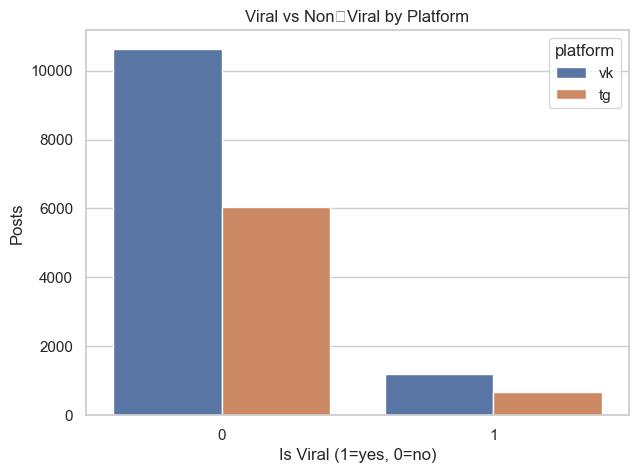

c:\Users\MSI\Desktop\Final_LU\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


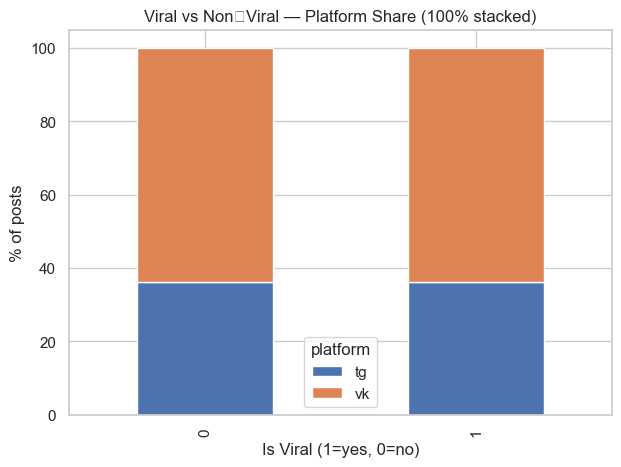

In [23]:
# гарантируем корректные типы
df["is_viral"] = pd.to_numeric(df["is_viral"], errors="coerce").fillna(0).astype(int)
df["platform"] = df["platform"].str.lower()

# Вариант A: сгруппированные столбики (hue=platform)
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="is_viral", hue="platform")
plt.title("Viral vs Non‑Viral by Platform")
plt.xlabel("Is Viral (1=yes, 0=no)")
plt.ylabel("Posts")
plt.show()

# Вариант B: 100% stacked bar (доля платформ в каждом классе)
ct = pd.crosstab(df["is_viral"], df["platform"])
pct = (ct.T / ct.T.sum()).T * 100.0
pct.plot(kind="bar", stacked=True, figsize=(7,5))
plt.title("Viral vs Non‑Viral — Platform Share (100% stacked)")
plt.xlabel("Is Viral (1=yes, 0=no)")
plt.ylabel("% of posts")
plt.legend(title="platform")
plt.show()

In [16]:
print(df.isna().sum())  # сколько пропусков в каждой колонке
print(np.isinf(df).sum()) 

platform                  0
source_name               0
source_link               0
followers                 0
post_id                   0
                         ..
mentions_per_100_chars    0
log_followers             0
has_fwd_src               0
has_fwd_msg_id            0
is_viral                  0
Length: 65, dtype: int64


TypeError: ufunc 'isinf' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [7]:
# import torch, numpy as np, pandas as pd, time
# from tqdm.auto import tqdm
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# MODEL_NAME = "blanchefort/rubert-base-cased-sentiment"
# MAX_LEN = 512
# BATCH_SIZE = 64  # на CPU можно 32

# # 1) загрузка
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device).eval()

# # 2) берём текст
# series_text = df["text"].fillna("").astype(str)

# # 3) порядок меток
# id2label = {int(k): str(v).upper() for k, v in getattr(model.config, "id2label", {0:"NEGATIVE",1:"NEUTRAL",2:"POSITIVE"}).items()}
# ordered_labels = [id2label[i] for i in sorted(id2label.keys())]
# col_map = {lab: i for i, lab in enumerate(ordered_labels)}

# # 4) инференс пачками
# all_probs = np.zeros((len(series_text), len(ordered_labels)), dtype=np.float32)
# t0 = time.time()
# with tqdm(total=len(series_text), desc=f"RuBERT sentiment ({device.type.upper()})", unit="rows") as pbar:
#     for start in range(0, len(series_text), BATCH_SIZE):
#         batch = series_text.iloc[start:start+BATCH_SIZE].tolist()
#         enc = tokenizer(batch, return_tensors="pt", truncation=True, max_length=MAX_LEN, padding=True)
#         enc = {k: v.to(device) for k, v in enc.items()}
#         with torch.no_grad():
#             logits = model(**enc).logits
#             probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
#         all_probs[start:start+len(batch), :] = probs
#         pbar.update(len(batch))
#         elapsed = time.time() - t0
#         speed = pbar.n / max(elapsed, 1e-6)
#         pbar.set_postfix({
#             "elapsed": f"{elapsed:.1f}s",
#             "speed": f"{speed:.1f} r/s"
#         })

# print(f"Done in {time.time()-t0:.1f}s, avg {len(series_text)/max(time.time()-t0,1e-6):.1f} rows/s")

# # 5) записываем в df
# df["neg_prob_hf"] = all_probs[:, col_map.get("NEGATIVE", 0)]
# df["neu_prob_hf"] = all_probs[:, col_map.get("NEUTRAL", 1)]
# df["pos_prob_hf"] = all_probs[:, col_map.get("POSITIVE", 2)]

# argmax_idx = all_probs.argmax(axis=1)
# df["sentiment_label_hf"] = pd.Series([ordered_labels[i] for i in argmax_idx], index=series_text.index)
# df["sentiment_num_hf"]   = df["sentiment_label_hf"].map({"NEGATIVE":-1,"NEUTRAL":0,"POSITIVE":1}).astype("Int64")
# df["sentiment_score_hf"] = df["pos_prob_hf"] - df["neg_prob_hf"]

# # 6) сохранение
# out_csv = "../data/processed/social_wide_final_enriched_sentiment.csv"
# df.to_csv(out_csv, index=False, encoding="utf-8-sig",
#           date_format="%Y-%m-%dT%H:%M:%S%z", float_format="%.6g")
# print("Saved:", out_csv)


import torch, numpy as np, pandas as pd, time, re, math
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "blanchefort/rubert-base-cased-sentiment"
MAX_LEN = 512
BATCH_SIZE = 64  # на CPU можно 32

# === анти-нейтральные "ручки" (крути под себя) ===
NEU_LOGIT_BIAS = -0.5   # штраф нейтрали на уровне логитов (от -0.3 до -0.8)
NEU_SHRINK     = 0.7    # сжать нейтраль после softmax (0.6–0.9)
ALPHA          = 0.45   # вес лексикона в гибридном скоре (0.3–0.6)
K_SIGMOID      = 3.0    # резкость сигмоиды при реконструкции p_pos/p_neg
MARGIN_EPS     = 0.08   # "тонкая победа" нейтрали
SCORE_EPS      = 0.025  # минимальная уверенность знака для переброса NEU -> POS/NEG

# === лексикон (минимальный, можно расширять) ===
POS_STEMS = [
    r"топ\w*", r"лучш\w*", r"шедевр\w*", r"круто\w*", r"класс\w*", r"супер\w*",
    r"бесплатн\w*", r"подешевел\w*", r"скидк\w*", r"хит\w*", r"новинк\w*",
    r"побед\w*", r"чемпион\w*", r"обладател\w*", r"выиграл\w*", r"рекорд\w*",
    r"вкусн\w*", r"кайф\w*", r"идеальн\w*", r"отличн\w*", r"огонь\w*", r"молодц\w*",
]
NEG_STEMS = [
    r"шок\w*", r"ужас\w*", r"страш\w*", r"жесть\w*", r"жесточайш\w*", r"паник\w*",
    r"зараж\w*", r"вирус\w*", r"болезн\w*", r"температур\w*", r"сып\w*",
    r"убил\w*", r"застрел\w*", r"насили\w*", r"преступлен\w*", r"скандал\w*", r"штраф\w*",
    r"запрет\w*", r"закрыт\w*", r"банкрот\w*", r"крах\w*", r"провал\w*",
    r"удар\w*", r"тревог\w*", r"ракет\w*", r"дрон\w*", r"кинджал\w*",
    r"депресс\w*", r"плач\w*", r"трагед\w*", r"катастроф\w*", r"авар\w*",
    r"мошенн\w*", r"фальсификат\w*", r"токсич\w*",
]
POS_PHRASES = [
    "высокий рейтинг","критики в восторге","первый трофей",
    "отличная возможность","сохраняем и смотрим","идеальный старт",
]
NEG_PHRASES = [
    "массово заражаются","воздушная тревога","массовые беспорядки",
    "убили","запретить в россии","угроза",
]
POS_PAT = re.compile(r"|".join(POS_STEMS), flags=re.IGNORECASE)
NEG_PAT = re.compile(r"|".join(NEG_STEMS), flags=re.IGNORECASE)

def lexicon_score(text: str) -> float:
    if not text: return 0.0
    t = text.lower()
    pos_hits = len(POS_PAT.findall(t))
    neg_hits = len(NEG_PAT.findall(t))
    for ph in POS_PHRASES:
        if ph in t: pos_hits += 2
    for ph in NEG_PHRASES:
        if ph in t: neg_hits += 2
    total = pos_hits + neg_hits
    if total == 0: return 0.0
    return (pos_hits - neg_hits) / total  # [-1..1]

# 1) загрузка
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# 2) берём текст
series_text = df["text"].fillna("").astype(str)

# 3) порядок меток
id2label = {int(k): str(v).upper() for k, v in getattr(model.config, "id2label", {0:"NEGATIVE",1:"NEUTRAL",2:"POSITIVE"}).items()}
ordered_labels = [id2label[i] for i in sorted(id2label.keys())]
col_map = {lab: i for i, lab in enumerate(ordered_labels)}
idx_neg = col_map.get("NEGATIVE", 0)
idx_neu = col_map.get("NEUTRAL", 1)
idx_pos = col_map.get("POSITIVE", 2)

# 4) инференс пачками (с учётом штрафа нейтрали на логитах)
all_probs = np.zeros((len(series_text), len(ordered_labels)), dtype=np.float32)
t0 = time.time()
with tqdm(total=len(series_text), desc=f"RuBERT sentiment ({device.type.upper()})", unit="rows") as pbar:
    for start in range(0, len(series_text), BATCH_SIZE):
        batch = series_text.iloc[start:start+BATCH_SIZE].tolist()
        enc = tokenizer(batch, return_tensors="pt", truncation=True, max_length=MAX_LEN, padding=True)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            # --- штраф нейтральному классу на логитах ---
            logits_adj = logits.clone()
            logits_adj[:, idx_neu] = logits_adj[:, idx_neu] + NEU_LOGIT_BIAS
            probs = torch.softmax(logits_adj, dim=-1).detach().cpu().numpy()
        all_probs[start:start+len(batch), :] = probs
        pbar.update(len(batch))
        elapsed = time.time() - t0
        speed = pbar.n / max(elapsed, 1e-6)
        pbar.set_postfix({"elapsed": f"{elapsed:.1f}s","speed": f"{speed:.1f} r/s"})

print(f"Done in {time.time()-t0:.1f}s, avg {len(series_text)/max(time.time()-t0,1e-6):.1f} rows/s")

# 4.1) постобработка против гипер-NEUTRAL
p_neg0 = all_probs[:, idx_neg].astype("float32")
p_neu0 = all_probs[:, idx_neu].astype("float32")
p_pos0 = all_probs[:, idx_pos].astype("float32")

# сжимаем нейтраль
p_neu = np.clip(p_neu0 * NEU_SHRINK, 1e-6, 1.0)
p_pos = np.clip(p_pos0, 1e-6, 1.0)
p_neg = np.clip(p_neg0, 1e-6, 1.0)
den = p_pos + p_neu + p_neg
p_pos /= den; p_neu /= den; p_neg /= den

# 4.2) лексикон и гибридный скор
lex_scores = series_text.map(lexicon_score).astype("float32").values
model_score = (p_pos0 - p_neg0)  # скаляр модели до усадки нейтрали
hybrid_score = (1.0 - ALPHA) * model_score + ALPHA * lex_scores

# реконструируем p_pos/p_neg из гибридного скора, учитывая нейтраль как "неуверенность"
sig = 1.0 / (1.0 + np.exp(-K_SIGMOID * hybrid_score))
p_pos_h = np.clip(sig * (1 - 0.5 * p_neu), 1e-6, 1.0)
p_neg_h = np.clip((1 - sig) * (1 - 0.5 * p_neu), 1e-6, 1.0)
p_neu_h = np.clip(p_neu * 0.9, 1e-6, 1.0)  # чуть поджали ещё раз

den_h = p_pos_h + p_neg_h + p_neu_h
p_pos_h /= den_h; p_neg_h /= den_h; p_neu_h /= den_h

# 4.3) правило маржи: ломаем слабую победу NEUTRAL в пользу знака
p_stack = np.vstack([p_neg_h, p_neu_h, p_pos_h]).T
argmax_idx = p_stack.argmax(axis=1)

labels = []
for i, m in enumerate(argmax_idx):
    top = p_stack[i, m]
    second = np.partition(p_stack[i], -2)[-2]
    margin = top - second
    if m == 1 and margin < MARGIN_EPS and abs(hybrid_score[i]) > SCORE_EPS:
        labels.append("POSITIVE" if hybrid_score[i] > 0 else "NEGATIVE")
    else:
        labels.append(["NEGATIVE", "NEUTRAL", "POSITIVE"][m])

# 5) записываем в df (обновляем колонки на "hybrid")
df["neg_prob_hf"] = p_neg_h.astype("float32")
df["neu_prob_hf"] = p_neu_h.astype("float32")
df["pos_prob_hf"] = p_pos_h.astype("float32")
df["sentiment_label_hf"] = pd.Series(labels, index=series_text.index)
df["sentiment_num_hf"]   = df["sentiment_label_hf"].map({"NEGATIVE":-1,"NEUTRAL":0,"POSITIVE":1}).astype("Int64")
df["sentiment_score_hf"] = (df["pos_prob_hf"] - df["neg_prob_hf"]).astype("float32")
df["sentiment_lexicon_score"] = lex_scores.astype("float32")  # на всякий случай — посмотреть вклад лексикона

# 6) сохранение
out_csv = "../data/processed/social_wide_final_enriched_sentiment.csv"
df.to_csv(out_csv, index=False, encoding="utf-8-sig",
          date_format="%Y-%m-%dT%H:%M:%S%z", float_format="%.6g")
print("Saved:", out_csv)





RuBERT sentiment (CPU):   0%|          | 0/18525 [00:00<?, ?rows/s]

Done in 4674.1s, avg 4.0 rows/s
Saved: ../data/processed/social_wide_final_enriched_sentiment.csv


In [2]:
out_csv = "../data/processed/social_wide_final_enriched_sentiment.csv"

df.to_csv(
    out_csv,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%dT%H:%M:%S%z",  # ISO8601; tz-aware будут в UTC с оффсетом
    float_format="%.6g"                  # компактнее числа
)

print("Saved:", out_csv)++

SyntaxError: invalid syntax (974505655.py, line 11)

In [3]:
df = pd.read_csv("../data/processed/social_wide_final_enriched_sentiment.csv")

C:\Users\MSI\AppData\Local\Temp\ipykernel_16580\2425927.py:1: DtypeWarning: Columns (5,12,16,24,25,27,32,33,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/social_wide_final_enriched_sentiment.csv")


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from tqdm import tqdm  # для красивого прогресса

# Загружаем модель и токенизатор
tokenizer = AutoTokenizer.from_pretrained("blanchefort/rubert-base-cased-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("blanchefort/rubert-base-cased-sentiment")

# Устройство: GPU если доступен
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Функция для одного текста
def classify_sentiment(text):
    try:
        inputs = tokenizer(str(text), return_tensors="pt", truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
        labels = ['negative', 'neutral', 'positive']
        return labels[np.argmax(probs)]
    except:
        return "neutral"  # fallback для пустых/невалидных текстов

# Применим ко всему DataFrame
tqdm.pandas()
df['sentiment_label2'] = df['text'].progress_apply(classify_sentiment)

100%|██████████| 18525/18525 [31:42<00:00,  9.74it/s]  


In [5]:
def get_sentiment_score(text):
    try:
        inputs = tokenizer(str(text), return_tensors="pt", truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
        return probs  # [neg, neutral, pos]
    except:
        return np.array([0.0, 1.0, 0.0])  # fallback to neutral

# get probabilities
df[['neg_prob', 'neu_prob', 'pos_prob']] = pd.DataFrame(
    df['text'].progress_apply(get_sentiment_score).tolist(),
    index=df.index
)

# sentiment_score — positive - negative
df['sentiment_score2'] = df['pos_prob'] - df['neg_prob']

100%|██████████| 18525/18525 [31:09<00:00,  9.91it/s]  


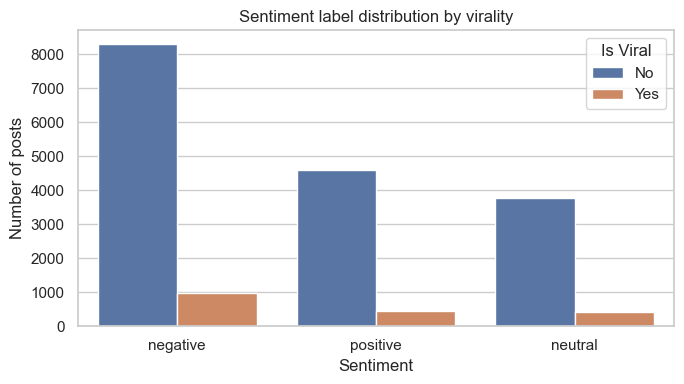

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(x='sentiment_label2', hue='is_viral', data=df)
plt.title("Sentiment label distribution by virality")
plt.xlabel("Sentiment")
plt.ylabel("Number of posts")
plt.legend(title="Is Viral", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

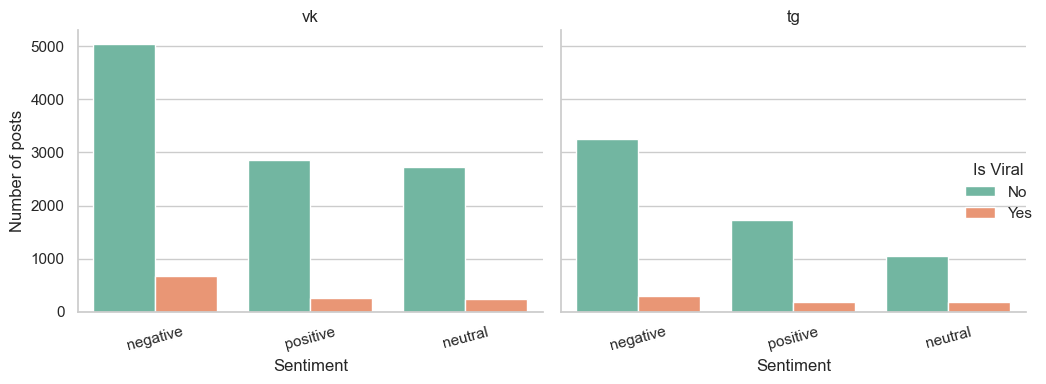

In [11]:
# берём только VK и TG и готовим подписи
df_plot = df.copy()
df_plot["platform"] = df_plot["platform"].astype(str).str.lower()
df_plot = df_plot[df_plot["platform"].isin(["vk", "tg"])].copy()

# красивый лейбл для легенды
df_plot["is_viral_str"] = np.where(df_plot["is_viral"].astype(int) == 1, "Yes", "No")

g = sns.catplot(
    data=df_plot,
    x="sentiment_label2",
    hue="is_viral_str",
    col="platform",
    kind="count",
    col_order=["vk", "tg"],
    hue_order=["No", "Yes"],
    height=4, aspect=1.2,
    palette="Set2"
)

g.set_axis_labels("Sentiment", "Number of posts")
g.set_titles("{col_name}")
g._legend.set_title("Is Viral")

# немного повернём подписи, если метки длинные
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(15)

plt.tight_layout()
plt.show()

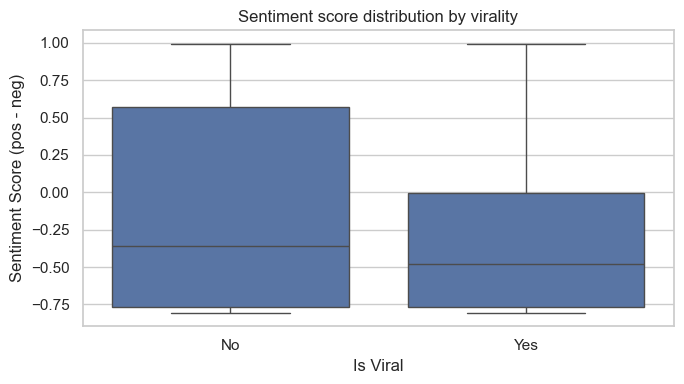

In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='is_viral', y='sentiment_score2', data=df)
plt.title("Sentiment score distribution by virality")
plt.xlabel("Is Viral")
plt.ylabel("Sentiment Score (pos - neg)")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

In [10]:
out_csv = "../data/processed/social_wide_final_enriched_sentiment1.csv"

df.to_csv(
    out_csv,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%dT%H:%M:%S%z",  # ISO8601; tz-aware будут в UTC с оффсетом
    float_format="%.6g"                  # компактнее числа
)

print("Saved:", out_csv)

Saved: ../data/processed/social_wide_final_enriched_sentiment1.csv


In [64]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Русские стоп-слова из nltk
stop_words = set(stopwords.words('russian'))

# Добавляем свои стоп-слова и одиночные буквы, цифры
extra_stopwords = {
    'л','г','ч','её','всё','лет','года','очень','который','это','вообще','ст',
    'тебе','также','такие','минут','день','просто','которые','пока','еще','ещё',
    'мл','шт','гр','лепру','будут','свой','своих','своей','свои','самые','самое','самый', 'club',
    'точно','a','the','to','black','club29573241','bankoffo','своего','такое','именно', 'прямо', 'всех','те', 'каждый',
    # часто встречающиеся цифры/числовые токены
    '0','1','2','3','4','5','6','7','8','9','10','24','25','26','27','28','30','31','32','39','54','62','97','154',
    # частые «мусорные» по твоему списку
    'несколько','которая','вместе','сразу','полностью'
}

stop_words.update(extra_stopwords)

# Отбираем вирусные посты
viral_texts = df.loc[df['is_viral'] == True, 'text'].astype(str).tolist()

words = []
for text in viral_texts:
    tokens = re.findall(r'\b\w+\b', text.lower())
    filtered = [word for word in tokens if word not in stop_words and not word.isdigit()]
    words.extend(filtered)

freq = Counter(words)

print("Топ-50 ключевых слов в вирусных постах без стоп-слов и цифр:")
for word, count in freq.most_common(50):
    print(f"{word}: {count}")


Топ-50 ключевых слов в вирусных постах без стоп-слов и цифр:
подписаться: 125
жизни: 70
время: 68
сегодня: 66
нужно: 50
жизнь: 50
человек: 49
людей: 47
россии: 46
детей: 39
новый: 39
дня: 38
рублей: 37
дней: 35
видео: 33
сша: 32
могут: 32
словам: 31
секс: 30
любовь: 29
лето: 29
люди: 28
скоро: 28
учёные: 27
год: 27
ингредиенты: 27
часов: 25
человека: 25
обязательно: 25
фильм: 24
мир: 24
хочу: 24
момент: 23
сериал: 23
девушка: 23
дома: 23
женщина: 23
всем: 23
уровень: 22
рф: 22
снова: 22
официально: 21
часть: 21
тысяч: 21
молоко: 21
найти: 20
самых: 20
сети: 20
netflix: 19
другие: 19


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


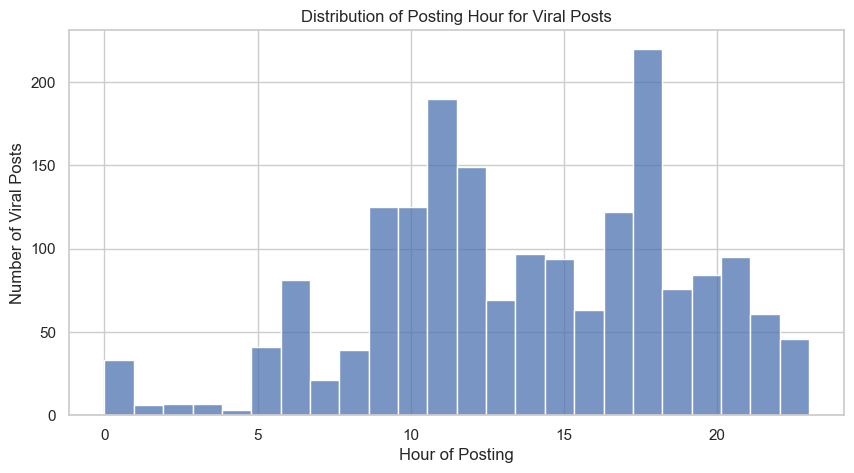

In [75]:
plt.figure(figsize=(10,5))
sns.histplot(data=df[df['is_viral']], x='hour_posted', bins=24)
plt.title('Distribution of Posting Hour for Viral Posts')
plt.xlabel('Hour of Posting')
plt.ylabel('Number of Viral Posts')
plt.show()



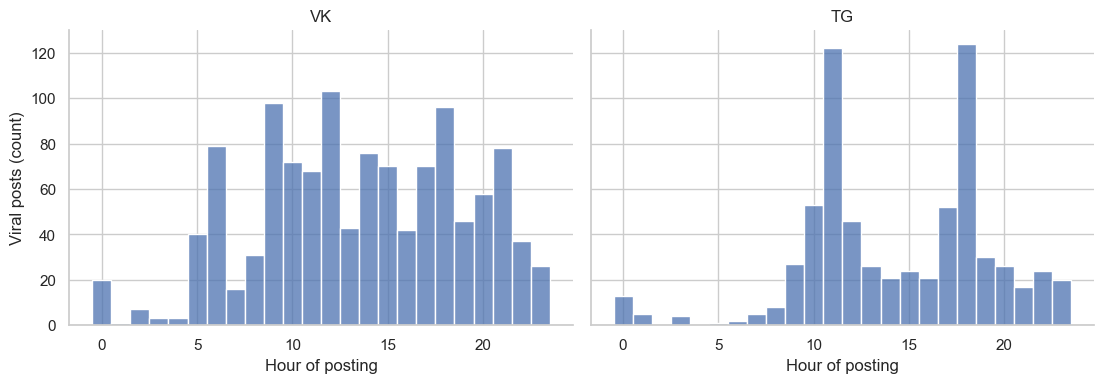

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sub = df.copy()
sub['platform_norm'] = (
    sub['platform'].astype(str).str.lower()
      .replace({'telegram':'tg', 'vkontakte':'vk'})
)
sub = sub[sub['platform_norm'].isin(['vk','tg'])].copy()
sub['platform_facet'] = sub['platform_norm'].map({'vk':'VK','tg':'TG'})
sub['is_viral'] = sub['is_viral'].astype(bool)

# привести часы к целым 0..23
sub['hour_posted'] = pd.to_numeric(sub['hour_posted'], errors='coerce').clip(0, 23).astype('Int64')

g = sns.displot(
    data=sub[sub['is_viral']],
    x='hour_posted',
    col='platform_facet',
    bins=range(0, 25),       # 24 бина по часам
    discrete=True,
    kde=False,
    height=4, aspect=1.4
)
g.set_axis_labels("Hour of posting", "Viral posts (count)")
g.set_titles(col_template="{col_name}")
plt.show()


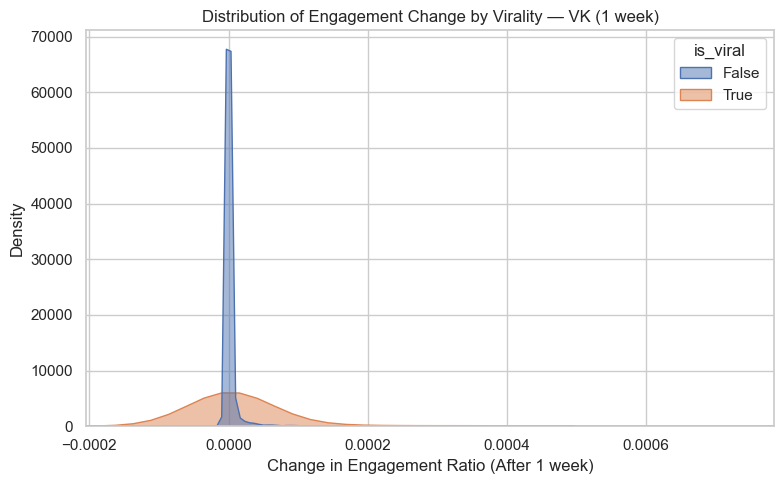

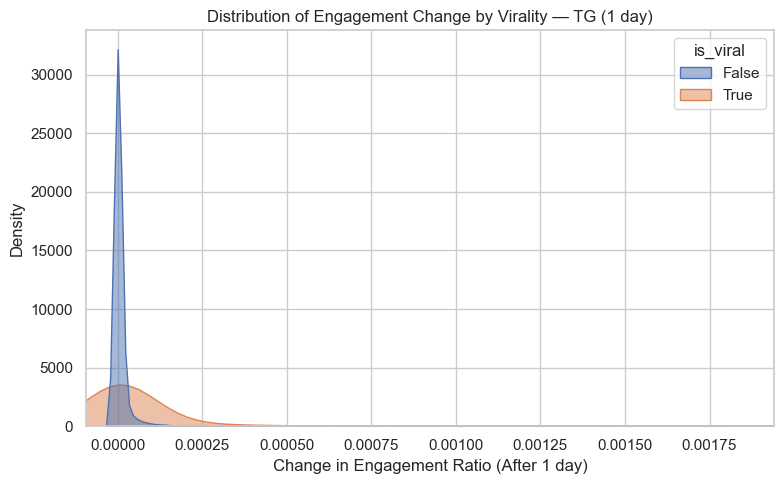

In [12]:
# Если колонки уже есть, этот блок просто пройдёт
if 'engagement_change' not in df.columns:
    assert {'er_final', 'engagement_rate'}.issubset(df.columns), \
        "Нет engagement_change и нечем посчитать (ожидаю er_final и engagement_rate)"
    df['engagement_change'] = df['er_final'] - df['engagement_rate']

# лёгкая очистка
df = df.copy()
df = df[np.isfinite(df['engagement_change'])]

def plot_kde_by_platform(data, platform_label: str, window_label: str):
    subset = data[data['platform'].str.upper() == platform_label.upper()].copy()
    if subset.empty:
        print(f"Нет данных для платформы: {platform_label}")
        return

    # динамические границы оси Х, чтобы не было огромных хвостов
    lo, hi = subset['engagement_change'].quantile([0.001, 0.999])
    pad = (hi - lo) * 0.05
    xmin, xmax = lo - pad, hi + pad

    plt.figure(figsize=(8,5))
    sns.kdeplot(
        data=subset, x='engagement_change', hue='is_viral',
        fill=True, common_norm=False, alpha=0.5
    )
    plt.title(f'Distribution of Engagement Change by Virality — {platform_label} ({window_label})')
    plt.xlabel(f'Change in Engagement Ratio (After {window_label})')
    plt.ylabel('Density')
    plt.xlim(xmin, xmax)
   
    plt.tight_layout()
    plt.show()

# 2 графика: VK (1 неделя) и TG (1 день)
plot_kde_by_platform(df, 'VK', '1 week')
plot_kde_by_platform(df, 'TG', '1 day')

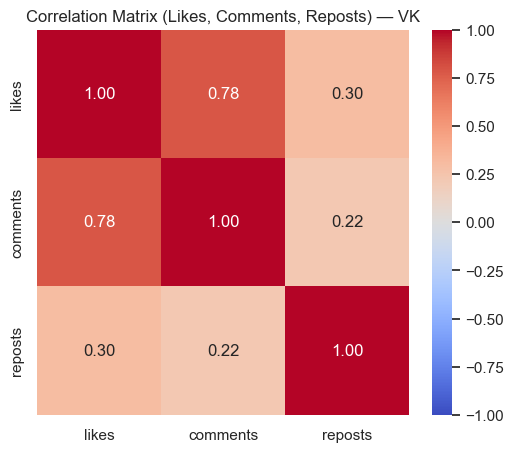

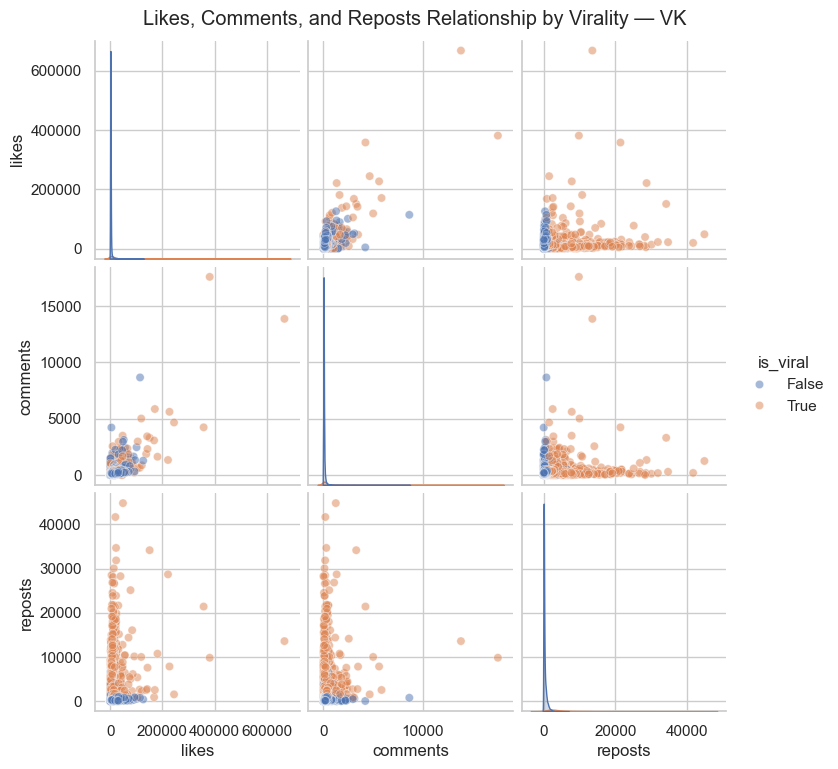

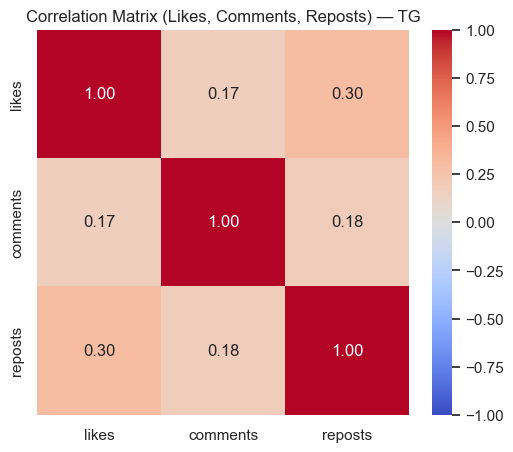

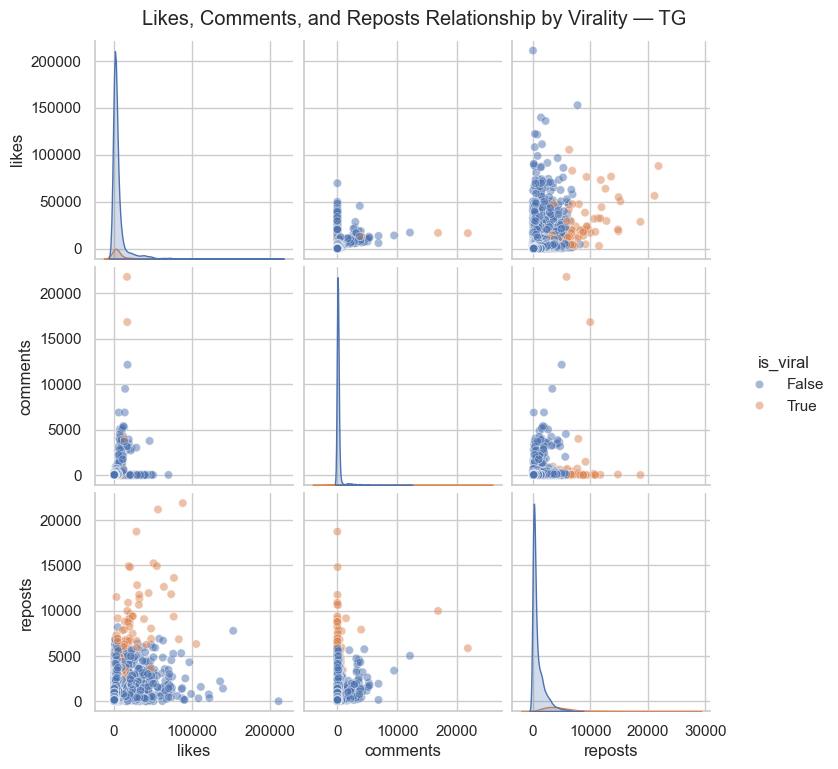

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_corr_and_pairs(data, platform_name):
    subset = data[data['platform'].str.lower() == platform_name.lower()].copy()
    if subset.empty:
        print(f"Нет данных для {platform_name}")
        return
    
    # Матрица корреляций
    corr = subset[['likes', 'comments', 'reposts']].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix (Likes, Comments, Reposts) — {platform_name.upper()}")
    plt.show()
    
    # Парные графики
    sns.pairplot(
        subset, vars=['likes', 'comments', 'reposts'],
        hue='is_viral', diag_kind='kde',
        plot_kws={'alpha':0.5}
    )
    plt.suptitle(f'Likes, Comments, and Reposts Relationship by Virality — {platform_name.upper()}', y=1.02)
    plt.show()

# Запускаем отдельно для VK и TG
plot_corr_and_pairs(df, "vk")
plot_corr_and_pairs(df, "tg")


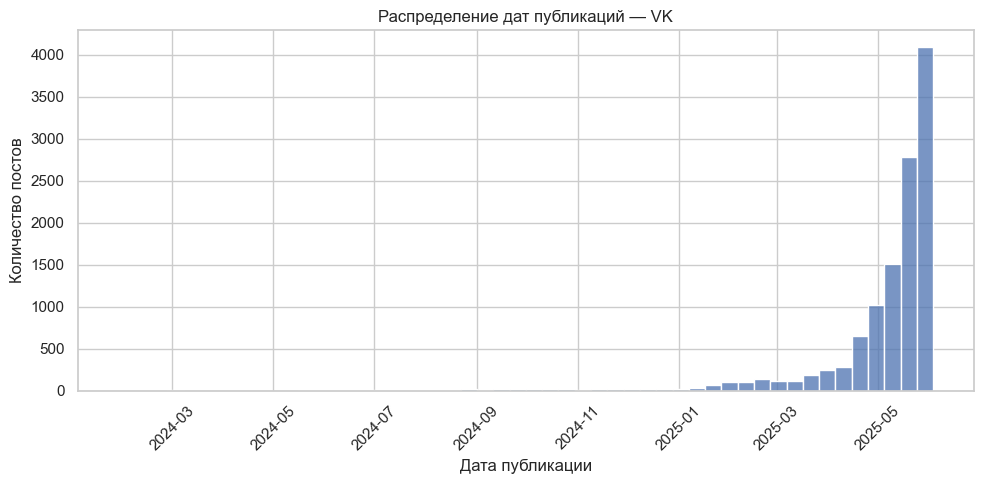

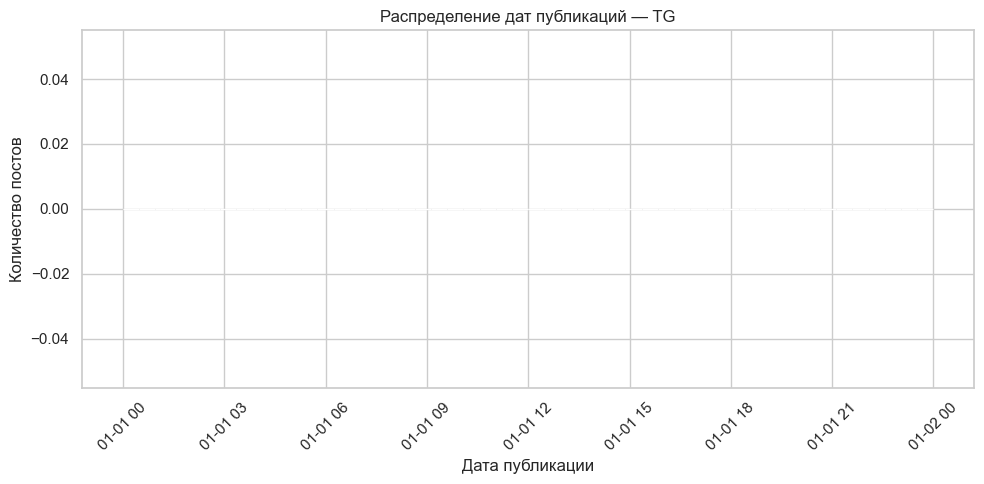

In [5]:
# убедимся, что даты приведены к datetime
df['published_at_dt'] = pd.to_datetime(df['published_at_dt'], errors='coerce')

# VK
vk = df[df['platform'].str.upper() == 'VK']
plt.figure(figsize=(10,5))
sns.histplot(vk['published_at_dt'], bins=50, kde=False)
plt.title("Распределение дат публикаций — VK")
plt.xlabel("Дата публикации")
plt.ylabel("Количество постов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TG
tg = df[df['platform'].str.upper() == 'TG']
plt.figure(figsize=(10,5))
sns.histplot(tg['published_at_dt'], bins=50, kde=False, color="orange")
plt.title("Распределение дат публикаций — TG")
plt.xlabel("Дата публикации")
plt.ylabel("Количество постов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'COL_NAME'

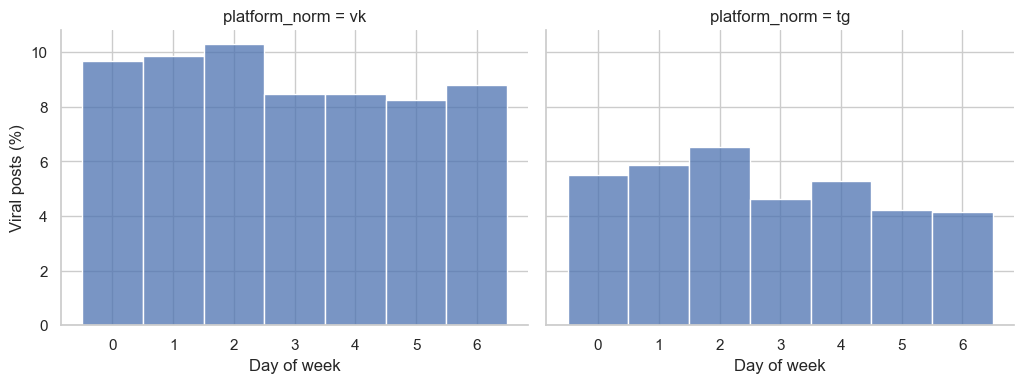

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Подготовка
sub = df.copy()
sub['platform_norm'] = (
    sub['platform'].astype(str).str.lower()
      .replace({'telegram':'tg','vkontakte':'vk'})
)
sub = sub[sub['platform_norm'].isin(['vk','tg'])].copy()
sub['is_viral'] = sub['is_viral'].astype(bool)

# dow_posted: 0..6 (Mon..Sun)
sub['dow_posted'] = pd.to_numeric(sub['dow_posted'], errors='coerce').astype('Int64')
day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

# --- Figure A: Day-of-week distribution (percent), only viral
d_viral = sub[sub['is_viral']].dropna(subset=['dow_posted'])

g = sns.displot(
    data=d_viral,
    x='dow_posted',
    col='platform_norm',
    bins=range(0,8),     # 0..6
    discrete=True,
    stat='percent',
    height=4, aspect=1.3
)
g.set_axis_labels("Day of week", "Viral posts (%)")
g.set_titles(col_template="{col_name}".upper())

# подпишем дни красиво
for ax in g.axes.flat:
    ax.set_xticks(range(0,7))
    ax.set_xticklabels([day_names[i] for i in range(7)])

plt.show()

# --- Figure B: Weekend vs Weekday share (percent), only viral
d_viral['is_weekend'] = d_viral['is_weekend'].astype('Int64')

week_share = (
    d_viral.groupby(['platform_norm','is_weekend'])
           .size()
           .groupby(level=0)
           .apply(lambda x: 100 * x / x.sum())
           .reset_index(name='percent')
)
week_share['label'] = week_share['is_weekend'].map({0:'Weekday', 1:'Weekend'})

g2 = sns.catplot(
    data=week_share,
    x='label', y='percent',
    col='platform_norm',
    kind='bar',
    height=4, aspect=1.0
)
g2.set_axis_labels("", "Viral posts (%)")
g2.set_titles(col_template="{col_name}".upper())
plt.show()


In [72]:
import os
import numpy as np
import pandas as pd

# ===== 1) Загрузка архива VK =====
def load_vk_archive(path_base="../data/processed/archive/vk_clean_with_sentiment"):
    # если уже есть расширение — используем как есть
    base, ext = os.path.splitext(path_base)
    candidates = [path_base] if ext else [path_base + ".csv", path_base + ".parquet"]
    for p in candidates:
        if os.path.exists(p):
            if p.endswith(".csv"):
                return pd.read_csv(p, low_memory=False)
            elif p.endswith(".parquet"):
                return pd.read_parquet(p)
    raise FileNotFoundError(f"Не найден файл {path_base}(.csv|.parquet)")

vk_arch = load_vk_archive()

# Проверим нужные столбцы
needed_cols = {"post_id", "date"}
missing = needed_cols - set(vk_arch.columns)
if missing:
    raise KeyError(f"В архиве нет столбцов: {missing}. Доступные: {list(vk_arch.columns)[:10]}...")

# Оставим уникальные пары post_id-date и переименуем date, чтобы не конфликтовал
vk_arch_slim = (vk_arch[["post_id", "date"]]
                .dropna(subset=["date"])
                .drop_duplicates(subset=["post_id"])
                .rename(columns={"date": "vk_date"}))

# ===== 2) Мержим в основной df по post_id =====
df = df.copy()
df = df.merge(vk_arch_slim, on="post_id", how="left")

# Маска VK
vk_mask = df["platform"].astype(str).str.lower().eq("vk")

# ===== 3) Парсим vk_date в datetime (поддержка unix секунд ИЛИ iso-строк) =====
# Сначала пробуем как числа секунд:
vk_date_num = pd.to_numeric(df.loc[vk_mask, "vk_date"], errors="coerce")
dt_from_num = pd.to_datetime(vk_date_num, unit="s", utc=True, errors="coerce")

# Что не распарсилось числом — пробуем как ISO/строку:
vk_date_str = df.loc[vk_mask, "vk_date"].where(vk_date_num.isna())
dt_from_str = pd.to_datetime(vk_date_str, utc=True, errors="coerce")

# Итог: где получилось число — берём его, иначе строку
dt_final = dt_from_num.fillna(dt_from_str)

# ===== 4) Обновляем ТОЛЬКО для VK нужные поля =====
# published_at_dt (UTC)
df.loc[vk_mask & dt_final.notna(), "published_at_dt"] = dt_final

# Локальное время (MSK) и производные
published_local = dt_final.dt.tz_convert("Europe/Moscow")

df.loc[vk_mask & dt_final.notna(), "hour_posted"] = published_local.dt.hour.astype("Int64")
df.loc[vk_mask & dt_final.notna(), "dow_posted"]   = published_local.dt.dayofweek.astype("Int64")
df.loc[vk_mask & dt_final.notna(), "is_weekend"]   = published_local.dt.dayofweek.isin([5, 6]).astype("Int8")

# (опционально, если у тебя есть столбец published_at_local и хочешь его тоже чинить)
# df.loc[vk_mask & dt_final.notna(), "published_at_local"] = published_local

# ===== 5) Диагностика =====
print("Обновлено VK-строк с валидной датой:", int((vk_mask & dt_final.notna()).sum()))
print("Число уникальных часов публикации VK (после фикса):",
      df.loc[vk_mask, "hour_posted"].nunique(dropna=True))

# Быстрый sanity-check распределений часов по VK
print(df.loc[vk_mask, "hour_posted"].value_counts(dropna=True).sort_index().head(10))


Обновлено VK-строк с валидной датой: 11823
Число уникальных часов публикации VK (после фикса): 24
hour_posted
0    365
1    126
2     75
3    135
4    109
5    236
6    286
7    288
8    463
9    593
Name: count, dtype: int64


In [73]:
import os, shutil
from pathlib import Path

# 0) Куда сохраняем
OUT = "../data/processed/social_wide_final_enriched_sentiment.csv"
OUT_DIR = Path(OUT).parent
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) (опционально) убрать временные поля, чтобы не тащить их в датасет
tmp_cols = [c for c in ["vk_date", "_lem", "platform_norm", "platform_facet", "hour_posted_fix"] if c in df.columns]
df_to_save = df.drop(columns=tmp_cols)

# 2) Бэкап, если файл уже есть
if Path(OUT).exists():
    shutil.copy2(OUT, OUT + ".bak")

# 3) Надёжная запись через временный файл (обходит блокировки/частичный write)
TMP = OUT + ".tmp"
df_to_save.to_csv(TMP, index=False, encoding="utf-8-sig")  # CSV ок с tz-aware датами (они сохранятся как строки ISO)
os.replace(TMP, OUT)  # атомарная замена

print(f"Сохранено: {OUT} (+ бэкап {OUT}.bak, если старый файл был)")


Сохранено: ../data/processed/social_wide_final_enriched_sentiment.csv (+ бэкап ../data/processed/social_wide_final_enriched_sentiment.csv.bak, если старый файл был)


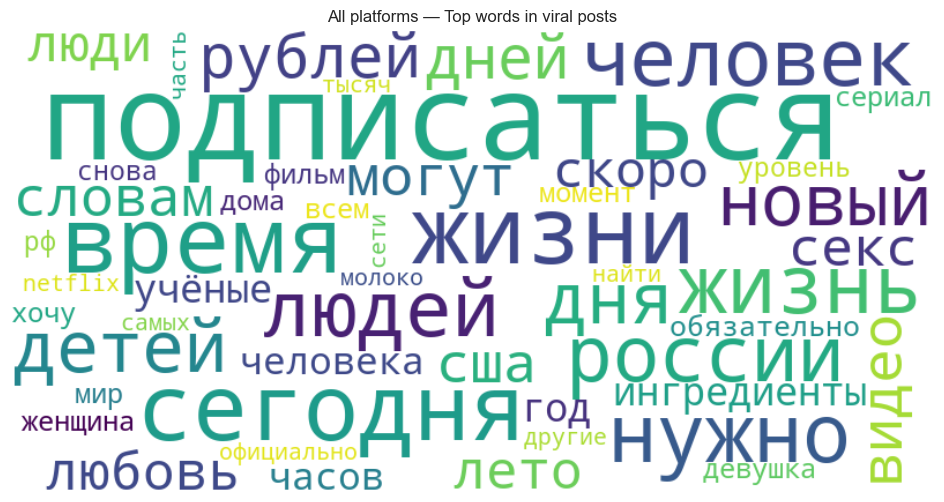

In [61]:
freq = dict(top_words_for_mask(df, df['is_viral'], k=50))

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800, height=400, background_color='white',
    max_words=100, colormap='viridis', random_state=42,
    # font_path=r"C:\Windows\Fonts\DejaVuSans.ttf"  # добавь, если нужна кириллица
).generate_from_frequencies(freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("All platforms — Top words in viral posts")
plt.show()

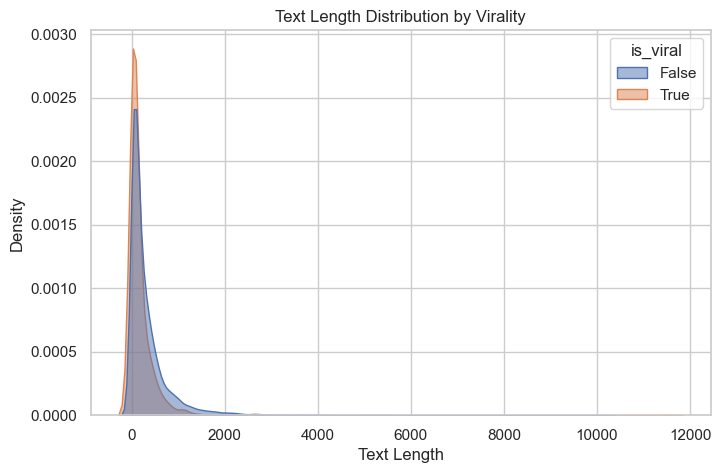

In [65]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='len_text', hue='is_viral', fill=True, common_norm=False, alpha=0.5)
plt.title('Text Length Distribution by Virality')
plt.xlabel('Text Length')
plt.ylabel('Density')
plt.show()


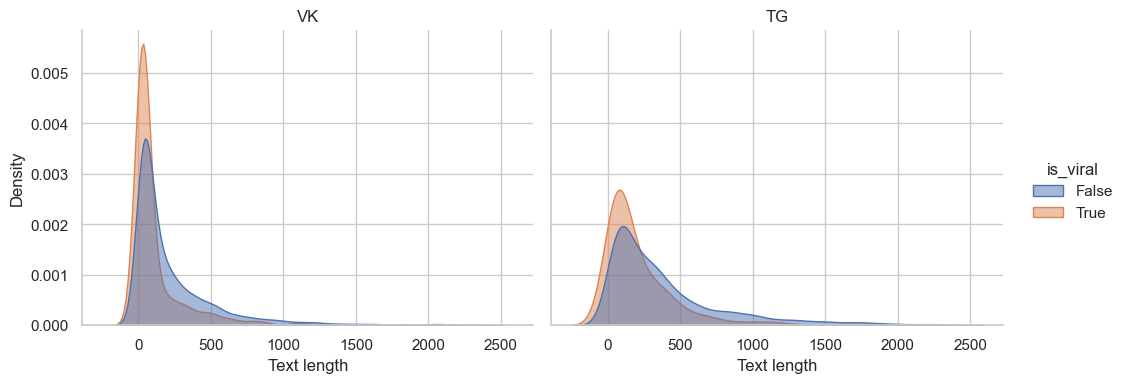

In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Нормализуем платформы и типы
df = df.copy()
df['platform_norm'] = (
    df['platform'].astype(str).str.lower()
      .replace({'telegram':'tg', 'vkontakte':'vk'})
)
df['is_viral'] = df['is_viral'].astype(bool)
df['len_text'] = pd.to_numeric(df['len_text'], errors='coerce')

sub = df[df['platform_norm'].isin(['vk','tg'])].dropna(subset=['len_text'])

# (опционально) обрежем экстремальный хвост, чтобы плотности читались
p99 = sub['len_text'].quantile(0.99)

# 2) Фасет по платформам
g = sns.displot(
    data=sub[(sub['len_text'] >= 0) & (sub['len_text'] <= p99)],
    x='len_text',
    hue='is_viral',
    col='platform_norm',
    kind='kde',
    fill=True,
    common_norm=False,
    height=4, aspect=1.3,
    alpha=0.5
)
g.set_axis_labels("Text length", "Density")
g.set_titles(col_template="{col_name}")  # <-- без .upper()
plt.title('Text Length Distribution by Virality')

for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title.upper())

plt.show()



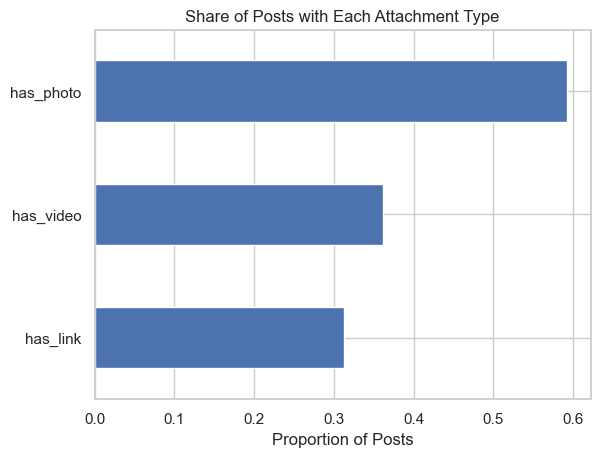

In [4]:
df[['has_photo', 'has_video', 'has_link']].mean().sort_values().plot(kind='barh')
plt.title("Share of Posts with Each Attachment Type")
plt.xlabel("Proportion of Posts")
plt.show()

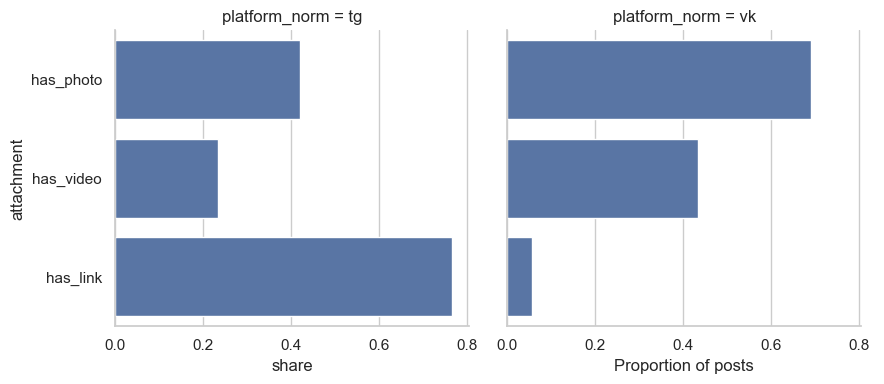

In [5]:
sub = df.copy()
sub['platform_norm'] = (
    sub['platform'].astype(str).str.lower()
      .replace({'telegram':'tg','vkontakte':'vk'})
)
sub = sub[sub['platform_norm'].isin(['vk','tg'])].copy()

# Приводим флаги к bool (на случай 'TRUE'/'False'/0/1/NaN)
has_cols = ['has_photo','has_video','has_link']
for c in has_cols:
    sub[c] = sub[c].astype(str).str.lower().map(
        {'true': True, '1': True, 'false': False, '0': False}
    ).fillna(False).astype(bool)

# Пропорции по платформам
prop = sub.groupby('platform_norm')[has_cols].mean().reset_index()
prop_long = prop.melt(id_vars='platform_norm', var_name='attachment', value_name='share')

sns.catplot(
    data=prop_long, x='share', y='attachment',
    col='platform_norm', kind='bar', height=4, aspect=1.1
)
plt.xlabel("Proportion of posts"); plt.ylabel("")
plt.show()



Share within Ad/Non-Ad (attachments):

has_photo:
has_photo          no       yes
is_ad_final                    
0            0.406891  0.593109
1            0.508287  0.491713

has_video:
has_video          no       yes
is_ad_final                    
0            0.638574  0.361426
1            0.690608  0.309392

has_link:
has_link           no       yes
is_ad_final                    
0            0.686655  0.313345
1            0.712707  0.287293

Mean engagement (overall):
             likes_final  comments_final  reposts_final
is_ad_final                                            
0            3659.324479       98.180471     950.622656
1              31.795580        1.784530       9.668508

Mean engagement by platform:
                           likes_final  comments_final  reposts_final
platform_norm is_ad_final                                            
tg            0            5630.197208      218.727580    1246.034020
vk            0            2883.299691       70.58

C:\Users\MSI\AppData\Local\Temp\ipykernel_5428\1748060738.py:76: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=melted_overall, x='metric', y='value', hue='is_ad_final', ci='sd')


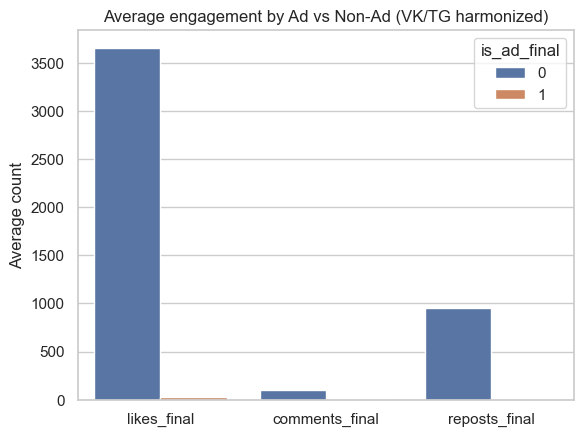

C:\Users\MSI\AppData\Local\Temp\ipykernel_5428\1748060738.py:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.catplot(


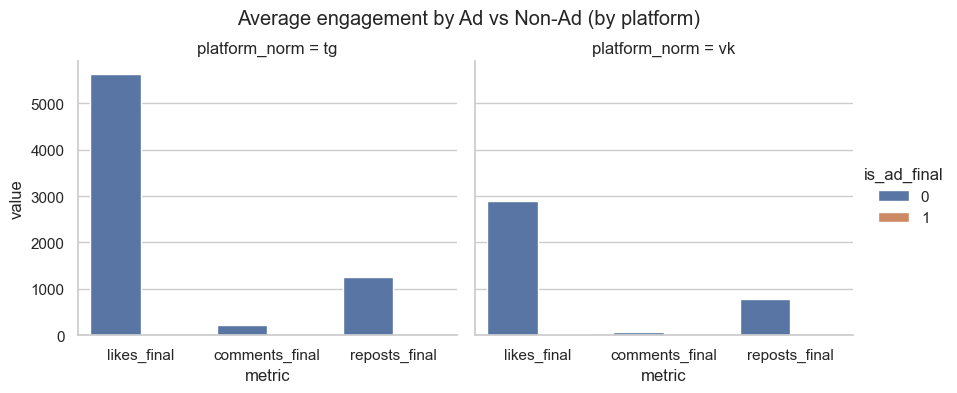

In [8]:


D = df.copy()

# --- нормализуем платформу
D['platform_norm'] = (
    D['platform'].astype(str).str.lower()
      .replace({'telegram':'tg','vkontakte':'vk'})
)

# --- робастная сборка is_ad_final
def to_bool_int(s):
    return s.astype(str).str.lower().isin(['1','true','yes','y','да']).astype(int)

D['is_ad_final'] = (
    to_bool_int(D.get('is_ad', pd.Series(False, index=D.index))) |
    to_bool_int(D.get('is_ad_my_classif', pd.Series(False, index=D.index)))
).astype(int)

# --- выбираем корректные engagement-колонки по платформе
vk_cols = {
    'likes':    'likes_2025-06-07',
    'comments': 'comments_2025-06-07',
    'reposts':  'reposts_2025-06-07',
}
tg_cols = {
    'likes':    'likes_2025-08-15',
    'comments': 'comments_2025-08-15',
    'reposts':  'reposts_2025-08-15',
}

# на случай отсутствия каких-то столбцов — создадим пустые
for c in [*vk_cols.values(), *tg_cols.values()]:
    if c not in D.columns:
        D[c] = np.nan

# гармонизированные метрики
mask_vk = D['platform_norm'].eq('vk')
mask_tg = D['platform_norm'].eq('tg')

D['likes_final']    = np.where(mask_vk,
                               pd.to_numeric(D[vk_cols['likes']], errors='coerce'),
                               pd.to_numeric(D[tg_cols['likes']], errors='coerce'))
D['comments_final'] = np.where(mask_vk,
                               pd.to_numeric(D[vk_cols['comments']], errors='coerce'),
                               pd.to_numeric(D[tg_cols['comments']], errors='coerce'))
D['reposts_final']  = np.where(mask_vk,
                               pd.to_numeric(D[vk_cols['reposts']], errors='coerce'),
                               pd.to_numeric(D[tg_cols['reposts']], errors='coerce'))

eng_cols_final = ['likes_final','comments_final','reposts_final']

# ===== Кросс-таб по вложениям (без изменений)
has_cols = ['has_photo','has_video','has_link']
for c in has_cols:
    if D[c].dtype != bool:
        D[c] = D[c].astype(str).str.lower().map({'true':True,'1':True,'false':False,'0':False}).fillna(False).astype(bool)

print("\nShare within Ad/Non-Ad (attachments):")
for c in has_cols:
    print(f"\n{c}:")
    print(pd.crosstab(D['is_ad_final'], D[c], normalize='index').rename(columns={False:'no', True:'yes'}))

# ===== Средние engagement: общие
print("\nMean engagement (overall):")
print(D.groupby('is_ad_final')[eng_cols_final].mean(numeric_only=True))

# ===== Средние engagement: по платформам
print("\nMean engagement by platform:")
print(D.groupby(['platform_norm','is_ad_final'])[eng_cols_final].mean(numeric_only=True))

# ===== Графики (overall)
melted_overall = (
    D.groupby('is_ad_final')[eng_cols_final].mean(numeric_only=True)
     .reset_index()
     .melt(id_vars='is_ad_final', var_name='metric', value_name='value')
)
sns.barplot(data=melted_overall, x='metric', y='value', hue='is_ad_final', ci='sd')
plt.title("Average engagement by Ad vs Non-Ad (VK/TG harmonized)")
plt.ylabel("Average count"); plt.xlabel("")
plt.show()

# ===== Графики (by platform)
melted_plat = (
    D.groupby(['platform_norm','is_ad_final'])[eng_cols_final].mean(numeric_only=True)
     .reset_index()
     .melt(id_vars=['platform_norm','is_ad_final'], var_name='metric', value_name='value')
)
sns.catplot(
    data=melted_plat, x='metric', y='value', hue='is_ad_final',
    col='platform_norm', kind='bar', height=4, aspect=1.1, ci='sd'
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Average engagement by Ad vs Non-Ad (by platform)")
plt.show()


             count  percent
is_ad_final                
Non-ad (0)   16825    90.82
Ad (1)        1700     9.18

Ad rate overall: 9.176788124156547 %

Counts by platform:
is_ad_final          0       1
platform_norm                 
tg              5462.0  1240.0
vk             11363.0   460.0

Percents by platform:
is_ad_final        0     1
platform_norm             
tg              81.5  18.5
vk             96.11  3.89


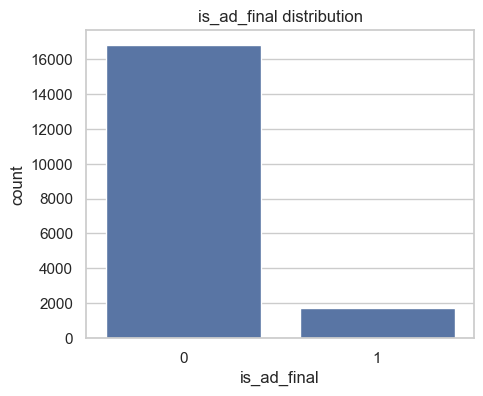

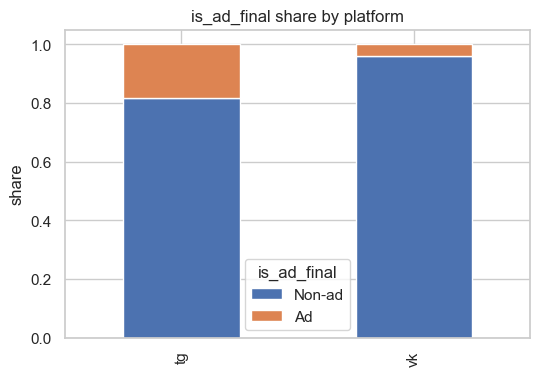

In [10]:

D = df.copy()
D['platform_norm'] = (
    D['platform'].astype(str).str.lower()
      .replace({'telegram':'tg','vkontakte':'vk'})
)

# привести is_ad_final к 0/1 (Int64), если вдруг лежит строками/True/False
D['is_ad_final'] = pd.to_numeric(D['is_ad_final'], errors='coerce').astype('Int64')

# --- 1) Общие количества и доли
cnt = D['is_ad_final'].value_counts(dropna=False)
pct = D['is_ad_final'].value_counts(normalize=True, dropna=False)*100
summary = pd.DataFrame({'count': cnt, 'percent': pct.round(2)})
print(summary.rename(index={0:'Non-ad (0)', 1:'Ad (1)', pd.NA:'NA'}))

# Быстрая оценка «редкости»
print("\nAd rate overall:", (D['is_ad_final']==1).mean()*100, "%")

# --- 2) По платформам (VK/TG)
by_plat = (
    D.groupby('platform_norm')['is_ad_final']
      .value_counts(dropna=False)
      .rename('count')
      .reset_index()
)
by_plat['percent'] = (
    by_plat.groupby('platform_norm')['count']
           .apply(lambda x: 100*x/x.sum())
           .values
).round(2)
print("\nCounts by platform:")
print(by_plat.pivot_table(index='platform_norm', columns='is_ad_final', values='count', fill_value=0))

print("\nPercents by platform:")
print(by_plat.pivot_table(index='platform_norm', columns='is_ad_final', values='percent', fill_value=0))

# --- 3) Графики
plt.figure(figsize=(5,4))
sns.countplot(data=D, x='is_ad_final')
plt.title('is_ad_final distribution'); plt.xlabel('is_ad_final'); plt.ylabel('count')
plt.show()

share_plat = (
    D.groupby('platform_norm')['is_ad_final']
      .value_counts(normalize=True)
      .unstack(fill_value=0)
      .rename(columns={0:'Non-ad', 1:'Ad'})
)
share_plat.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('is_ad_final share by platform'); plt.ylabel('share'); plt.xlabel('')
plt.show()


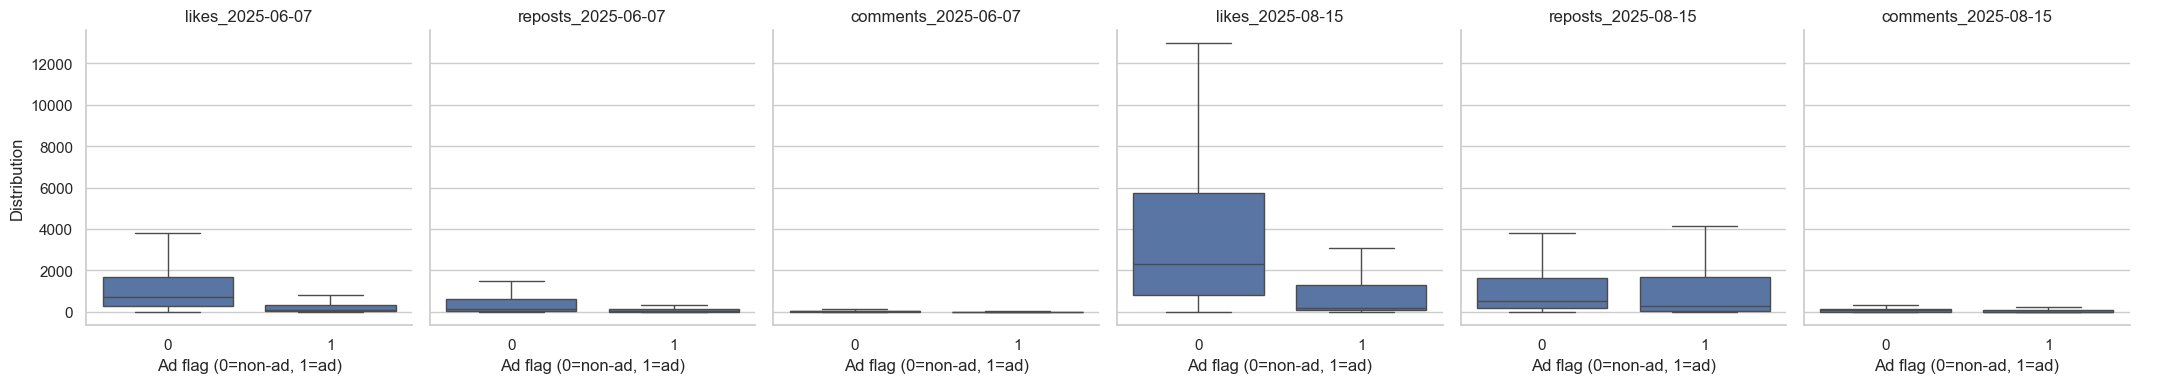

In [9]:

# если у тебя уже есть `melted` (variable, value, is_ad_final) — можно пропустить этот блок
eng_cols = [c for c in ['likes_2025-06-07','reposts_2025-06-07','comments_2025-06-07',
                        'likes_2025-08-15','reposts_2025-08-15','comments_2025-08-15',
                        'likes_final','comments_final','reposts_final'] if c in df.columns]
melted = (df[['is_ad_final']+eng_cols]
          .melt(id_vars='is_ad_final', var_name='variable', value_name='value'))
melted['value'] = pd.to_numeric(melted['value'], errors='coerce')

# boxplot по каждой метрике (без выбросов, чтобы шкала читалась)
g = sns.catplot(
    data=melted, x='is_ad_final', y='value', col='variable',
    kind='box', showfliers=False, height=4, aspect=0.9
)
g.set_axis_labels("Ad flag (0=non-ad, 1=ad)", "Distribution")
g.set_titles(col_template="{col_name}")
plt.show()


C:\Users\MSI\AppData\Local\Temp\ipykernel_5428\4026642844.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


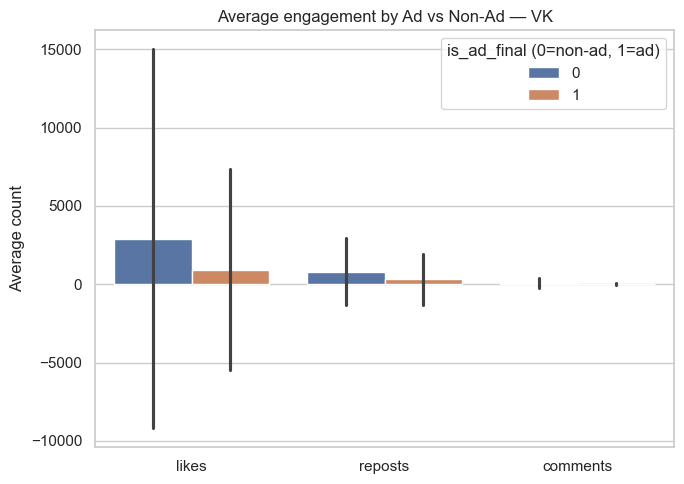

C:\Users\MSI\AppData\Local\Temp\ipykernel_5428\4026642844.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


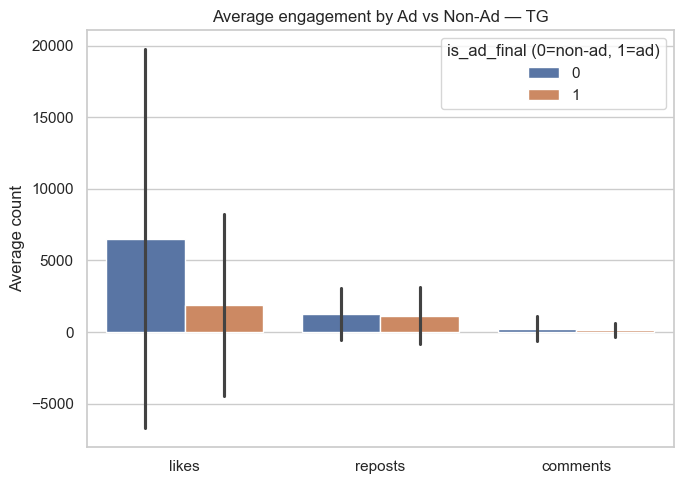

In [13]:

D = df.copy()
D['platform_norm'] = (
    D['platform'].astype(str).str.lower()
      .replace({'telegram':'tg','vkontakte':'vk'})
)

# приведение is_ad_final к 0/1
D['is_ad_final'] = pd.to_numeric(D['is_ad_final'], errors='coerce').fillna(0).astype(int)

# какие столбцы брать для сырых счётчиков
VK_MAP = {'likes':'likes_2025-06-07', 'reposts':'reposts_2025-06-07', 'comments':'comments_2025-06-07'}
TG_MAP = {'likes':'likes_2025-08-15', 'reposts':'reposts_2025-08-15','comments':'comments_2025-08-15'}

def melted_for_platform(data, plat):
    m = data[data['platform_norm'].eq(plat)].copy()
    cols = VK_MAP if plat=='vk' else TG_MAP
    for c in cols.values():
        if c not in m.columns: m[c] = np.nan
    m = (m[['is_ad_final', cols['likes'], cols['reposts'], cols['comments']]]
         .rename(columns={
             cols['likes']:'likes', cols['reposts']:'reposts', cols['comments']:'comments', 
         })
         .melt(id_vars='is_ad_final', var_name='variable', value_name='value'))
    m['value'] = pd.to_numeric(m['value'], errors='coerce')
    return m

def plot_platform(plat, title):
    M = melted_for_platform(D, plat).dropna(subset=['value'])
    plt.figure(figsize=(7,5))
    sns.barplot(
        data=M, x='variable', y='value',
        hue='is_ad_final', estimator=np.mean, ci='sd'
    )
    plt.title(f"Average engagement by Ad vs Non-Ad — {title}")
    plt.ylabel("Average count"); plt.xlabel("")
    plt.legend(title='is_ad_final (0=non-ad, 1=ad)')
    plt.tight_layout()
    plt.show()

# --- рисуем два графика: VK и TG
plot_platform('vk', 'VK')
plot_platform('tg', 'TG')


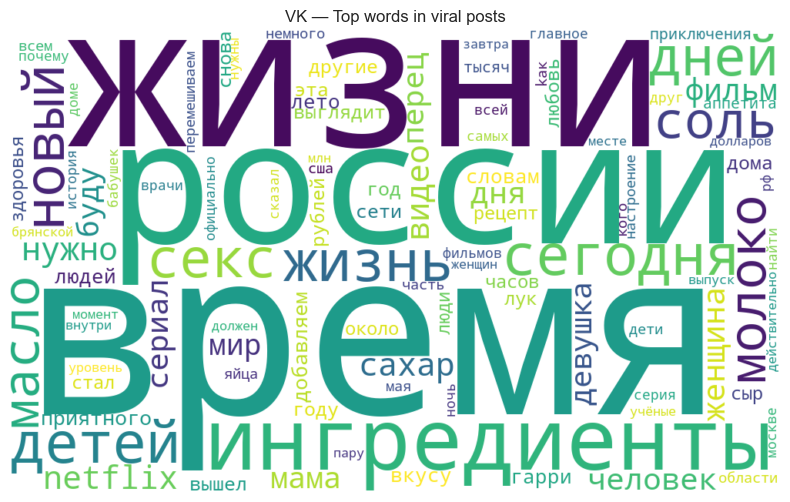

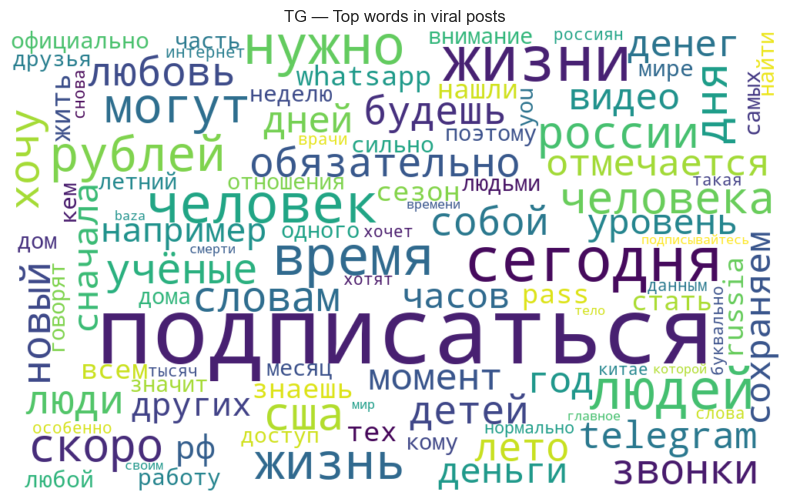

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# частоты (top-k побольше, чтобы было из чего строить облако)
freq_vk = dict(top_by_platform(df, 'vk', k=100))
freq_tg = dict(top_by_platform(df, 'tg', k=100))  # если у тебя 'telegram' — поменяй на 'telegram'

# опционально шрифт с кириллицей:
# font_path = r"C:\Windows\Fonts\DejaVuSans.ttf"
font_path = None

# VK
wc_vk = WordCloud(
    width=1000, height=600, background_color='white',
    max_words=150, colormap='viridis', random_state=42,
    font_path=font_path
).generate_from_frequencies(freq_vk)

plt.figure(figsize=(12, 6))
plt.imshow(wc_vk, interpolation='bilinear')
plt.axis('off')
plt.title("VK — Top words in viral posts")
plt.show()

# TG
wc_tg = WordCloud(
    width=1000, height=600, background_color='white',
    max_words=150, colormap='viridis', random_state=42,
    font_path=font_path
).generate_from_frequencies(freq_tg)

plt.figure(figsize=(12, 6))
plt.imshow(wc_tg, interpolation='bilinear')
plt.axis('off')
plt.title("TG — Top words in viral posts")
plt.show()
